# ImageNet-1K — Visualize Dataset and Loader

Load pre-built ImageNet caches and visualize samples through the
full SlipstreamLoader pipeline.

## Configuration

In [1]:
import os
from pathlib import Path

os.environ['SLIPSTREAM_CACHE_DIR'] = '/home/jovyan/work/DataLocal/.cache/slipstream/'

# Cache locations (adjust if needed)
CACHE_BASE = Path(os.environ.get("SLIPSTREAM_CACHE_DIR", Path.home() / ".slipstream"))

JPEG_VAL = CACHE_BASE / "imagenet1k-s256_l512-jpeg-val"
JPEG_TRAIN = CACHE_BASE / "imagenet1k-s256_l512-jpeg-train"
YUV_VAL = CACHE_BASE / "imagenet1k-s256_l512-yuv420-val"
YUV_TRAIN = CACHE_BASE / "imagenet1k-s256_l512-yuv420-train"

for name, path in [("JPEG val", JPEG_VAL), ("JPEG train", JPEG_TRAIN),
                    ("YUV val", YUV_VAL), ("YUV train", YUV_TRAIN)]:
    status = "ok" if (path / "manifest.json").exists() else "not found"
    print(f"{name:12s}: {status}  ({path})")

JPEG val    : ok  (/home/jovyan/work/DataLocal/.cache/slipstream/imagenet1k-s256_l512-jpeg-val)
JPEG train  : ok  (/home/jovyan/work/DataLocal/.cache/slipstream/imagenet1k-s256_l512-jpeg-train)
YUV val     : ok  (/home/jovyan/work/DataLocal/.cache/slipstream/imagenet1k-s256_l512-yuv420-val)
YUV train   : ok  (/home/jovyan/work/DataLocal/.cache/slipstream/imagenet1k-s256_l512-yuv420-train)


## Load a cache and inspect samples

In [2]:
from slipstream import SlipstreamDataset

dataset = SlipstreamDataset(local_dir=str(JPEG_VAL))
print(f"Samples: {len(dataset):,}")
print(f"Fields: {dataset.field_types}")

/home/jovyan/work/GitHub/slipstream/.venv/lib/python3.11/site-packages/numba/np/ufunc/parallel.py:373: NumbaWarning: The TBB threading layer requires TBB version 2021 update 6 or later i.e., TBB_INTERFACE_VERSION >= 12060. Found TBB_INTERFACE_VERSION = 12050. The TBB threading layer is disabled.
  warnings.warn(problem)


Samples: 50,000
Fields: {'image': 'ImageBytes', 'label': 'int', 'index': 'int', 'path': 'str'}


Label: 0, Path: n01440764/ILSVRC2012_val_00000293.JPEG, Size: (341, 256)


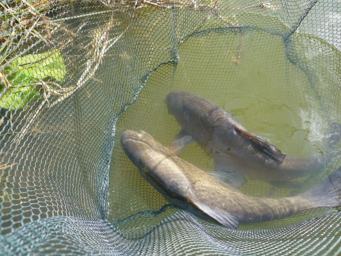

In [3]:
# View a single decoded sample
from PIL import Image
import io

sample = dataset[0]
img = Image.open(io.BytesIO(sample['image']))
print(f"Label: {sample['label']}, Path: {sample['path']}, Size: {img.size}")
img

## Validation loader

Loaded cache: 50,000 samples, 4 fields
  Loaded indexes: ['label']
Images: torch.Size([16, 3, 224, 224])


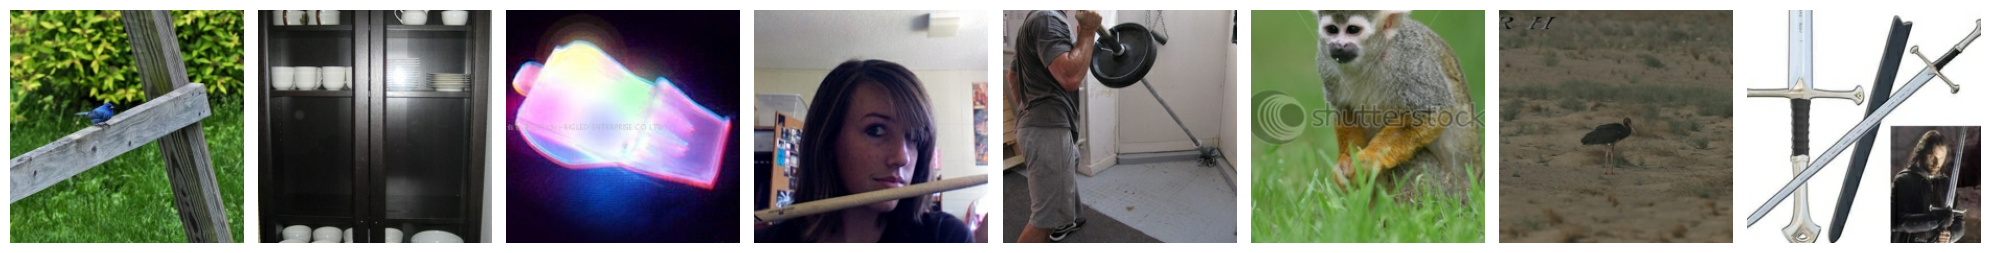

In [17]:
from slipstream import SlipstreamLoader
from slipstream.decoders import DecodeCenterCrop
from slipstream.transforms import ToTorchImage
from slipstream import show_batch

loader = SlipstreamLoader(
    dataset,
    batch_size=16,
    pipelines={"image": [DecodeCenterCrop(224), ToTorchImage('cpu')]},
    exclude_fields=["path"],
    seed=42,
)

batch = next(iter(loader))
print(f"Images: {batch['image'].shape}")
show_batch(batch['image'], batch['label'], n_cols=8)

## Training loader (RandomResizedCrop)

Loaded cache: 1,281,167 samples, 4 fields
  Loaded indexes: ['label']


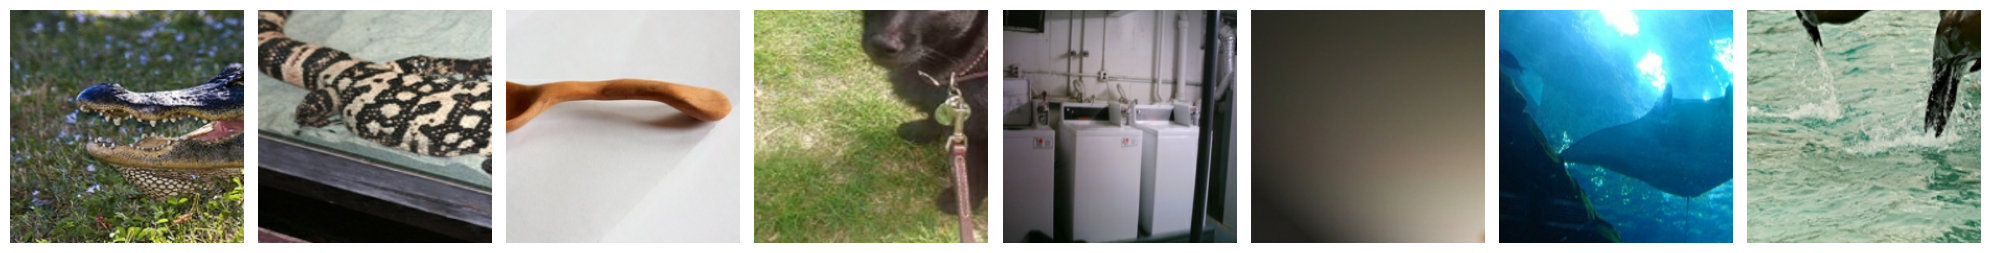

In [19]:
from slipstream.decoders import DecodeRandomResizedCrop
from slipstream.transforms import ToTorchImage

dataset = SlipstreamDataset(local_dir=str(JPEG_TRAIN))

train_loader = SlipstreamLoader(
    dataset,
    batch_size=16,
    shuffle=True,
    pipelines={"image": [DecodeRandomResizedCrop(224), ToTorchImage('cpu') ]},
    exclude_fields=["path"],
    seed=42,
)

batch = next(iter(train_loader))
show_batch(batch['image'], batch['label'], n_cols=8)

In [ ]:
loader.shutdown()
train_loader.shutdown()

## Compare JPEG vs YUV420

Loaded cache: 50,000 samples, 4 fields
  Loaded indexes: ['label']
Cache stores images as YUV420 (non-JPEG source), using YUV420 decoder
YUV420 CenterCrop:


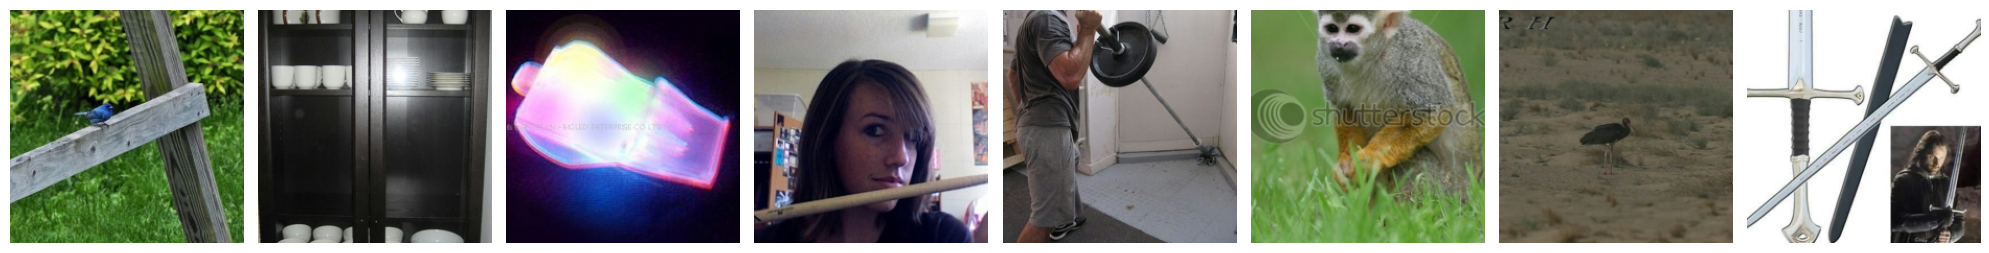

In [15]:
if (YUV_VAL / "manifest.json").exists():
    yuv_dataset = SlipstreamDataset(local_dir=str(YUV_VAL))

    yuv_loader = SlipstreamLoader(
        yuv_dataset,
        batch_size=16,
        pipelines={"image": [DecodeCenterCrop(224), ToTorchImage('cpu')]},
        exclude_fields=["path"],
        seed=42,
    )

    batch_yuv = next(iter(yuv_loader))
    print("YUV420 CenterCrop:")
    show_batch(batch_yuv['image'], batch_yuv['label'], n_cols=8)
    yuv_loader.shutdown()
else:
    print("YUV420 val cache not found — skip")

Loaded cache: 1,281,167 samples, 4 fields
  Loaded indexes: ['label']
Cache stores images as YUV420 (non-JPEG source), using YUV420 decoder
YUV420 CenterCrop:


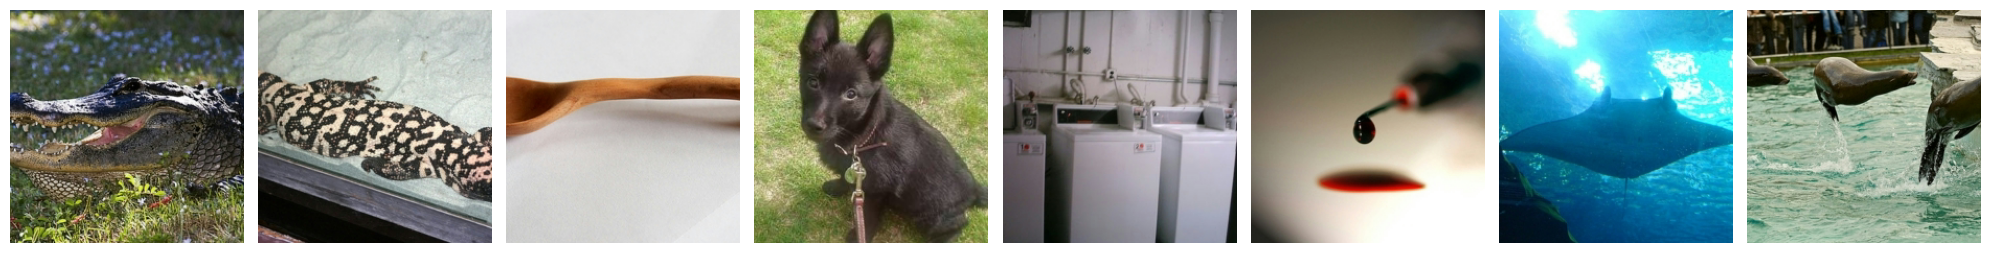

In [18]:
if (YUV_VAL / "manifest.json").exists():
    yuv_dataset = SlipstreamDataset(local_dir=str(YUV_TRAIN))

    yuv_loader = SlipstreamLoader(
        yuv_dataset,
        batch_size=16,
        pipelines={"image": [DecodeCenterCrop(224), ToTorchImage('cpu')]},
        exclude_fields=["path"],
        seed=42,
    )

    batch_yuv = next(iter(yuv_loader))
    print("YUV420 CenterCrop:")
    show_batch(batch_yuv['image'], batch_yuv['label'], n_cols=8)
    yuv_loader.shutdown()
else:
    print("YUV420 val cache not found — skip")